In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

In [2]:
import sys
sys.path.append("../modules")

import utils
import ThreeLayers.langevin as langevin
import ThreeLayers.FastProcessing.sampling as sampling

In [3]:
MInput = 5
MProcessing = 3
MOutput = 1

sigma_input = 0.9
sigma_processing = 0.9

np.random.seed(0)
A_input = np.random.randn(MInput, MInput)*sigma_input/np.sqrt(MInput)
A_input[np.diag_indices(MInput)] = 1

A_processing = np.random.randn(MProcessing, MProcessing)*sigma_processing/np.sqrt(MProcessing)
A_processing[np.diag_indices(MProcessing)] = 1

A_output = np.eye(MOutput)

Sigma_input = scipy.linalg.solve_continuous_lyapunov(A_input, 2*np.eye(MInput))
Sigma_processing = scipy.linalg.solve_continuous_lyapunov(A_processing, 2*np.eye(MProcessing))
Sigma_output = scipy.linalg.solve_continuous_lyapunov(A_output, 2*np.eye(MOutput))

g_PI = 5
g_OP = 5
sigma_OP_low = 1
sigma_OP_high = 2.5
A_PI = np.random.randn(MProcessing, MInput)

A_OP_high = np.random.randn(MOutput, MProcessing) * sigma_OP_high
A_OP_low = np.random.randn(MOutput, MProcessing) * sigma_OP_low

NSamples = int(1e6)

In [4]:
_, _, output_samples_NS_high_sigmaintPR = sampling.sample_nonlinearsum(NSamples,
                                                                       Sigma_input, Sigma_processing, Sigma_output,
                                                                       A_input, A_processing, A_output,
                                                                       A_PI, A_OP_high,
                                                                       g_PI, g_OP, auto_NMax = True, tanh_threshold = 1e-2)


_, _, output_samples_INT_high_sigmaintPR = sampling.sample_integrated(NSamples,
                                                                      Sigma_input, Sigma_processing, Sigma_output,
                                                                      A_input, A_processing, A_output,
                                                                      A_PI, A_OP_high,
                                                                      g_PI, g_OP, auto_NMax = True, tanh_threshold = 1e-2)

/Users/giorgionicoletti/Library/CloudStorage/OneDrive/ICTP/projects/NonlinarIntegrationAndSummation/notebooks/../modules/ThreeLayers/FastProcessing/sampling.py:348: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  mean_change = 1/MProcessing * np.dot(A_OP, mean_processing[:, idx])


In [5]:
_, _, output_samples_NS_low_sigmaintPR = sampling.sample_nonlinearsum(NSamples,
                                                                      Sigma_input, Sigma_processing, Sigma_output,
                                                                      A_input, A_processing, A_output,
                                                                      A_PI, A_OP_low,
                                                                      g_PI, g_OP, auto_NMax = True, tanh_threshold = 1e-2) 

_, _, output_samples_INT_low_sigmaintPR = sampling.sample_integrated(NSamples,
                                                                     Sigma_input, Sigma_processing, Sigma_output,
                                                                     A_input, A_processing, A_output,
                                                                     A_PI, A_OP_low,
                                                                     g_PI, g_OP, auto_NMax = True, tanh_threshold = 1e-2)

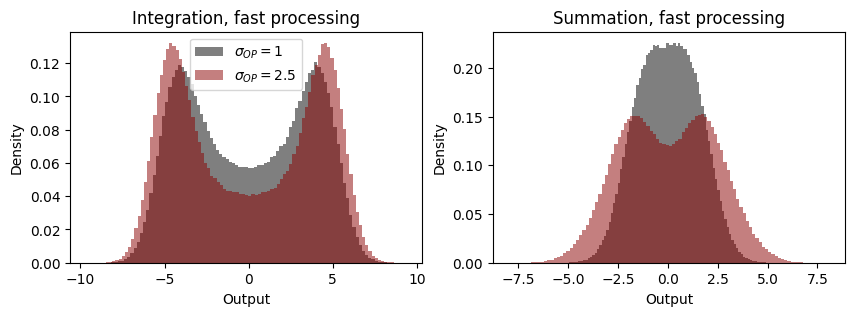

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(output_samples_INT_low_sigmaintPR[0], bins=100, color='black', alpha=0.5, density=True,
           label = f"$\sigma_{{OP}} = {sigma_OP_low}$")
ax[0].hist(output_samples_INT_high_sigmaintPR[0], bins=100, color='darkred', alpha=0.5, density=True,
           label = f"$\sigma_{{OP}} = {sigma_OP_high}$")
ax[0].set_xlabel("Output")
ax[0].set_ylabel("Density")
ax[0].set_title("Integration, fast processing")
ax[0].legend()

ax[1].hist(output_samples_NS_low_sigmaintPR[0], bins=100, color='black', alpha=0.5, density=True,
           label = f"$\sigma_{{OP}} = {sigma_OP_low}$")
ax[1].hist(output_samples_NS_high_sigmaintPR[0], bins=100, color='darkred', alpha=0.5, density=True,
           label = f"$\sigma_{{OP}} = {sigma_OP_high}$")
ax[1].set_xlabel("Output")
ax[1].set_ylabel("Density")
ax[1].set_title("Summation, fast processing")

plt.show()

In [7]:
MI_IO_INT_low_sigmaintPR = utils.get_MI_1D_output(output_samples_INT_low_sigmaintPR[0], Sigma_output[0, 0])
MI_IO_INT_high_sigmaintPR = utils.get_MI_1D_output(output_samples_INT_high_sigmaintPR[0], Sigma_output[0, 0])

MI_IO_NS_low_sigmaintPR = utils.get_MI_1D_output(output_samples_NS_low_sigmaintPR[0], Sigma_output[0, 0])
MI_IO_NS_high_sigmaintPR = utils.get_MI_1D_output(output_samples_NS_high_sigmaintPR[0], Sigma_output[0, 0])

print(f"Input-output mutual information (Integration, sigma_OP = {sigma_OP_low}): {MI_IO_INT_low_sigmaintPR}")
print(f"Input-output mutual information (Summation, sigma_OP = {sigma_OP_low}): {MI_IO_NS_low_sigmaintPR}")
print()
print(f"Input-output mutual information (Integration, sigma_OP = {sigma_OP_high}): {MI_IO_INT_high_sigmaintPR}")
print(f"Input-output mutual information (Summation, sigma_OP = {sigma_OP_high}): {MI_IO_NS_high_sigmaintPR}")

Input-output mutual information (Integration, sigma_OP = 1): 1.6160878182000977
Input-output mutual information (Summation, sigma_OP = 1): 0.585363425075927

Input-output mutual information (Integration, sigma_OP = 2.5): 1.6350944588844643
Input-output mutual information (Summation, sigma_OP = 2.5): 1.1621811293802202


In [8]:
NSteps = int(1e6)
dt = 5e-3
tau_input = 5e2
tau_output = 1e0
tau_processing = 5e-2
NRep = 64

lang_res = langevin.trajectory_statistics_NS_INT(NRep, NSteps, dt,
                                                 tau_input, tau_processing, tau_output,
                                                 A_input, A_processing, A_output,
                                                 A_PI, A_OP_low, g_PI, g_OP,
                                                 NBurn = int(1e5))

x_output_NS, x_output_INT = lang_res
lang_res = None

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


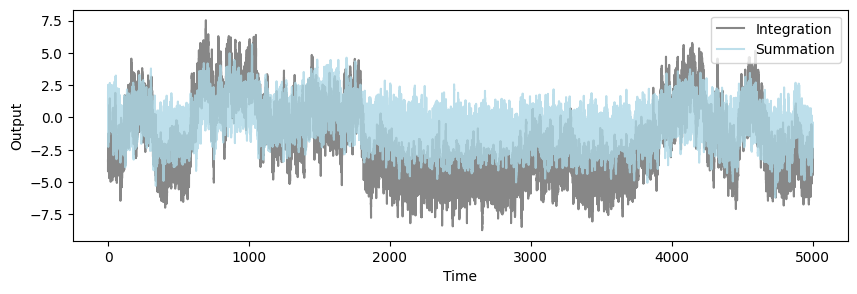

In [11]:
Time = np.arange(NSteps) * dt
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(Time, x_output_INT[1], color='dimgray', alpha=0.8, label="Integration")
ax.plot(Time, x_output_NS[1], color='lightblue', alpha=0.8, label="Summation")

ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend(loc='upper right')
plt.show()

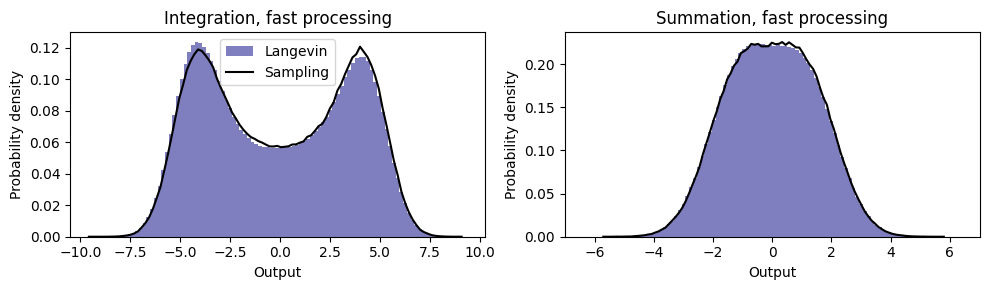

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(x_output_INT.flatten(), bins=100, color='navy', alpha=0.5, density=True, label = "Langevin")
xtemp, ytemp = np.histogram(output_samples_INT_low_sigmaintPR, bins=100, density=True)
ax[0].plot(0.5*(ytemp[1:]+ytemp[:-1]), xtemp, color='k', label="Sampling")

ax[0].set_xlabel("Output")
ax[0].set_ylabel("Probability density")
ax[0].set_title("Integration, fast processing")
ax[0].legend()

ax[1].hist(x_output_NS.flatten(), bins=100, color='navy', alpha=0.5, density=True)
xtemp, ytemp = np.histogram(output_samples_NS_low_sigmaintPR, bins=100, density=True)
ax[1].plot(0.5*(ytemp[1:]+ytemp[:-1]), xtemp, color='k')

ax[1].set_xlabel("Output")
ax[1].set_ylabel("Probability density")
ax[1].set_title("Summation, fast processing")

plt.tight_layout()
plt.show()